In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/TRAFFIC/urban_traffic_dataset.csv")
df.head()


,timestamp,road_id,vehicle_count,avg_speed,traffic_density,signal_wait_time,lane_count,weather,hour,day_type,congestion_level
0,2024-01-01 00:00:00,R104,177,42,18,36,2,1,21,1,0
1,2024-01-01 00:05:00,R105,170,42,32,11,2,0,20,0,0
2,2024-01-01 00:10:00,R103,163,29,21,147,3,2,22,1,0
3,2024-01-01 00:15:00,R105,33,25,97,28,3,2,18,1,1
4,2024-01-01 00:20:00,R105,90,30,71,123,4,2,20,0,1


In [3]:
features = [
    "vehicle_count",
    "avg_speed",
    "traffic_density",
    "signal_wait_time",
    "lane_count",
    "weather",
    "hour",
    "day_type"
]

X = df[features].values
y = df["congestion_level"].values


In [4]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
def create_sequences(X, y, time_steps=5):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_seq, y_seq = create_sequences(X_scaled, y, TIME_STEPS)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False
)

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)


In [7]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    
    LSTM(32),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 5, 64)               │          18,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,259 (126.01 KB)

 Trainable params: 32,259 (126.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=30,
    batch_size=32
)


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6609 - loss: 0.8435 - val_accuracy: 0.6587 - val_loss: 0.8308
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6772 - loss: 0.8016 - val_accuracy: 0.6587 - val_loss: 0.8290
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6772 - loss: 0.8029 - val_accuracy: 0.6587 - val_loss: 0.8312
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 0.8015 - val_accuracy: 0.6587 - val_loss: 0.8313
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 0.8019 - val_accuracy: 0.6587 - val_loss: 0.8283
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 0.8024 - val_accuracy: 0.6587 - val_loss: 0.8281
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 0.7989 - val_accuracy: 0.6587 - val_loss: 0.8295
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 0.8006 - val_accuracy: 0.

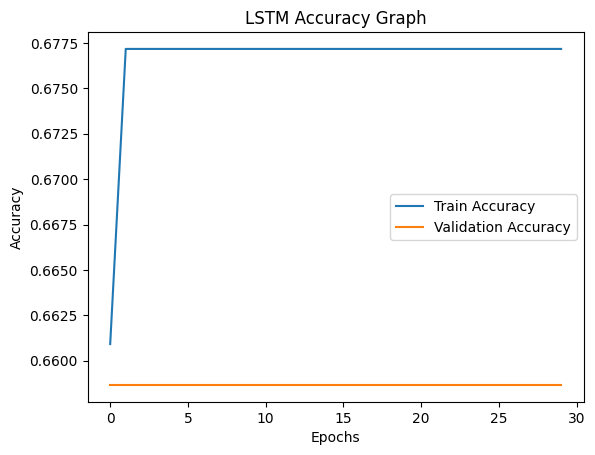

In [9]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("LSTM Accuracy Graph")
plt.show()


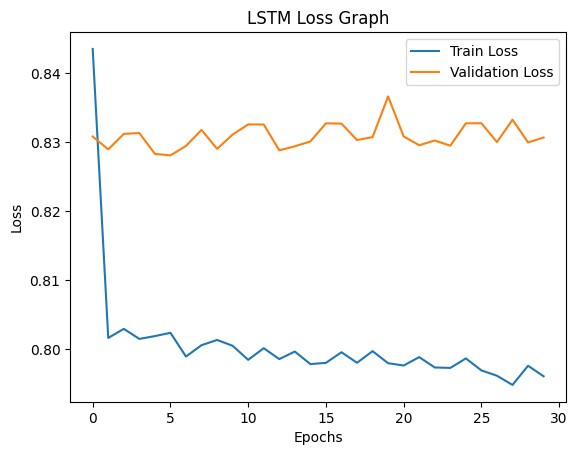

In [10]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("LSTM Loss Graph")
plt.show()


In [11]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [12]:
accuracy = accuracy_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print("✅ Accuracy :", accuracy)
print("📉 RMSE     :", rmse)
print("📉 MAE      :", mae)
print("🎯 F1-Score :", f1)


✅ Accuracy : 0.6586586586586587
📉 RMSE     : 0.762614962862375
📉 MAE      : 0.4214214214214214
🎯 F1-Score : 0.5231109202141186


In [13]:
model.save("traffic_lstm_model.h5")
print("✅ Model saved as traffic_lstm_model.h5")


✅ Model saved as traffic_lstm_model.h5
